### モンテカルロ法と強化学習
+ 環境モデル$p(s'|s,a)$と$r(s,a,s')$が複雑でブラックボックスな場合に適用する。
+ モンテカルロ法はエージェントが実際にエピソード経験を通して(状態,行動,報酬)のデータを得た後に、環境モデルを推定する(大数の法則)

例) 二つの🎲の目の和の確率分布をモンてカルロ法で求める

In [1]:
# 確率分布から期待値を求める(確率分布は事前にパターンを列挙して求めている)
ps = {
    2: 1/36,
    3: 2/36,
    4: 3/36,
    5: 4/36,
    6: 5/36,
    7: 6/36,
    8: 5/36,
    9: 4/36,
    10: 3/36,
    11: 2/36,
    12: 1/36
}

V = 0
for x, p in ps.items():
    V += x * p # 確率変数 * 確率

print(f"V: {V}") # 期待値

V: 6.999999999999999


分布モデル(解析的)とサンプルモデル(数値計算的)

In [2]:
# サンプルモデル
import numpy as np

def sample(dices=2):
    x = 0
    for _ in range(dices):
        x += np.random.choice([1,2,3,4,5,6])
    return x

In [3]:
print(sample())
print(sample())
print(sample())
print(sample())
print(sample())
print(sample())
print(sample())

11
11
7
10
5
7
9


モンテカルロ法によって期待値を求めるコード

In [4]:
trial = 10000

samples = []

for _ in range(trial):
    s = sample()
    samples.append(s)

V = sum(samples) / len(samples) # 平均
print(V)

6.9983


サンプルデータを得るたびに平均値をモンテカルロ法で求める

In [5]:
trial = 100
samples = []
for epoch in range(trial):
    s = sample()
    samples.append(s)
    V = sum(samples) / len(samples) # 平均
    print(f"[{epoch}]: V {V}")

[0]: V 9.0
[1]: V 7.5
[2]: V 7.333333333333333
[3]: V 6.25
[4]: V 6.0
[5]: V 6.0
[6]: V 6.142857142857143
[7]: V 6.875
[8]: V 7.333333333333333
[9]: V 7.3
[10]: V 7.363636363636363
[11]: V 7.0
[12]: V 6.6923076923076925
[13]: V 6.642857142857143
[14]: V 6.666666666666667
[15]: V 6.6875
[16]: V 6.764705882352941
[17]: V 6.722222222222222
[18]: V 6.7894736842105265
[19]: V 7.0
[20]: V 7.0
[21]: V 7.045454545454546
[22]: V 7.043478260869565
[23]: V 7.083333333333333
[24]: V 7.24
[25]: V 7.153846153846154
[26]: V 7.037037037037037
[27]: V 6.964285714285714
[28]: V 6.931034482758621
[29]: V 6.833333333333333
[30]: V 6.870967741935484
[31]: V 6.9375
[32]: V 6.878787878787879
[33]: V 6.911764705882353
[34]: V 6.8
[35]: V 6.694444444444445
[36]: V 6.756756756756757
[37]: V 6.7631578947368425
[38]: V 6.871794871794871
[39]: V 6.875
[40]: V 7.0
[41]: V 7.0
[42]: V 7.046511627906977
[43]: V 6.9772727272727275
[44]: V 6.911111111111111
[45]: V 6.913043478260869
[46]: V 6.957446808510638
[47]: V 6.

インクリメンタルに価値関数(平均)を求める更新式
$$V_{n} = V_{n-1} + \frac{1}{n}(s_{n} - V_{n-1})$$

In [14]:
# インクリメンタルな価値関数の更新式
# V(n) = V(n-1) + (1/n) * (s(n) - V(n-1))

trial = 1000
V_incremental = 0
for n in range(1, trial + 1):
    sn = sample()
    V_incremental = V_incremental + (1/n) * (sn - V_incremental)
    if n % 10 == 0 or n == 1:
        print(f"[{n}]: V {V_incremental}")

print(f"\n最終的な価値関数: {V_incremental}")

[1]: V 7.0
[10]: V 6.3999999999999995
[20]: V 7.1499999999999995
[30]: V 7.066666666666666
[40]: V 6.824999999999999
[50]: V 6.5600000000000005
[60]: V 6.500000000000002
[70]: V 6.52857142857143
[80]: V 6.612500000000002
[90]: V 6.58888888888889
[100]: V 6.630000000000002
[110]: V 6.7272727272727275
[120]: V 6.758333333333334
[130]: V 6.838461538461537
[140]: V 6.8928571428571415
[150]: V 6.88
[160]: V 6.8875
[170]: V 6.8999999999999995
[180]: V 6.805555555555555
[190]: V 6.821052631578947
[200]: V 6.875000000000001
[210]: V 6.885714285714286
[220]: V 6.9318181818181825
[230]: V 6.947826086956521
[240]: V 6.904166666666668
[250]: V 6.924
[260]: V 6.95
[270]: V 6.922222222222222
[280]: V 6.910714285714285
[290]: V 6.910344827586205
[300]: V 6.919999999999999
[310]: V 6.887096774193547
[320]: V 6.909374999999999
[330]: V 6.939393939393938
[340]: V 6.923529411764705
[350]: V 6.925714285714285
[360]: V 6.975000000000001
[370]: V 6.943243243243245
[380]: V 6.942105263157896
[390]: V 6.94615

### 方策が与えられた時にモンテカルロ法での方策評価方法
$$v_{\pi}(s) = E_{\pi}[G|s]$$

+ エピソードiで状態sからスタートした時に獲得した収益は$G^{(i)}$
+ 収益は未来に対する期待値なので、エピソードが終端まで進んで初めて得られる
+ 1エピソードが状態空間の$\forall s \in S$における1回のサンプリング
+ $V_{\pi}(s)$は, 状態sスタートにおけるそのエピソードの価値関数

$$V_{\pi}(s) = \frac{\sum G^{(i)}}{n}$$

* モンテカルロ法はエピソードタスクのみ適用可能


##### 全ての状態　$\exists s \in S$　に関する価値関数$V_{\pi}(s)$を求める

+ 状態Aからスタートして方策$\pi$に従って行動し、1エピソード(状態はA→B→Cで遷移)を終えた場合の収益
$$G_{A} = R_{0} + \gamma R_{1} + \gamma^{2} R_{2}$$

+ 状態Bからスタートして得られた場合の収益は下記
$$G_{B} = R_{1} + \gamma R_{2} $$

+ 状態Cからスタートして得られた場合の収益は下記
$$G_{C} = R_{2}$$

* エピソードを繰り返すうちに全ての状態 $\forall s \in S$ を経由できれば、全ての状態についての収益のサンプルが得られる

##### 最後の$G_{C}$からエピソードを逆に辿って各状態の収益$G_{s}$を求める
$$G_{C} = R_{2}$$
$$G_{B} = R_{1} + \gamma G_{C}$$
$$G_{A} = R_{0} + \gamma G_{B}$$
+ これがモンテカルロ法による方策評価の方法

#### 3x4グリッドワールド環境におけるロボット(エージェント)の各状態の収益を求める

In [ ]:
# 描画用
import numpy as np
import matplotlib
import matplotlib_inline
import matplotlib.pyplot as plt

class Renderer:
    def __init__(self, reward_map, goal_state, wall_state):
        self.reward_map = reward_map
        self.goal_state = goal_state
        self.wall_state = wall_state
        self.ys = len(self.reward_map)
        self.xs = len(self.reward_map[0])

        self.ax = None
        self.fig = None
        self.first_flg = True

    def set_figure(self, figsize=None):
        fig = plt.figure(figsize=figsize)
        self.ax = fig.add_subplot(111)
        ax = self.ax
        ax.clear()
        ax.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False)
        ax.set_xticks(range(self.xs))
        ax.set_yticks(range(self.ys))
        ax.set_xlim(0, self.xs)
        ax.set_ylim(0, self.ys)
        ax.grid(True)

    def render_v(self, v=None, policy=None, print_value=True):
        self.set_figure()

        ys, xs = self.ys, self.xs
        ax = self.ax

        if v is not None:
            color_list = ['red', 'white', 'green']
            cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
                'colormap_name', color_list)

            # dict -> ndarray
            v_dict = v
            v = np.zeros(self.reward_map.shape)
            for state, value in v_dict.items():
                v[state] = value

            vmax, vmin = v.max(), v.min()
            vmax = max(vmax, abs(vmin))
            vmin = -1 * vmax
            vmax = 1 if vmax < 1 else vmax
            vmin = -1 if vmin > -1 else vmin

            ax.pcolormesh(np.flipud(v), cmap=cmap, vmin=vmin, vmax=vmax)

        for y in range(ys):
            for x in range(xs):
                state = (y, x)
                r = self.reward_map[y, x]
                if r != 0 and r is not None:
                    txt = 'R ' + str(r)
                    if state == self.goal_state:
                        txt = txt + ' (GOAL)'
                    ax.text(x+.1, ys-y-0.9, txt)

                if (v is not None) and state != self.wall_state:
                    if print_value:
                        offsets = [(0.4, -0.15), (-0.15, -0.3)]
                        key = 0
                        if v.shape[0] > 7: key = 1
                        offset = offsets[key]
                        ax.text(x+offset[0], ys-y+offset[1], "{:12.2f}".format(v[y, x]))

                if policy is not None and state != self.wall_state:
                    actions = policy[state]
                    max_actions = [kv[0] for kv in actions.items() if kv[1] == max(actions.values())]

                    arrows = ["↑", "↓", "←", "→"]
                    offsets = [(0, 0.1), (0, -0.1), (-0.1, 0), (0.1, 0)]
                    for action in max_actions:
                        arrow = arrows[action]
                        offset = offsets[action]
                        if state == self.goal_state:
                            continue
                        ax.text(x+0.45+offset[0], ys-y-0.5+offset[1], arrow)

                if state == self.wall_state:
                    ax.add_patch(plt.Rectangle((x,ys-y-1), 1, 1, fc=(0.4, 0.4, 0.4, 1.)))
        plt.show()

    def render_q(self, q, show_greedy_policy=True):
        self.set_figure()

        ys, xs = self.ys, self.xs
        ax = self.ax
        action_space = [0, 1, 2, 3]

        qmax, qmin = max(q.values()), min(q.values())
        qmax = max(qmax, abs(qmin))
        qmin = -1 * qmax
        qmax = 1 if qmax < 1 else qmax
        qmin = -1 if qmin > -1 else qmin


        color_list = ['red', 'white', 'green']
        cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
            'colormap_name', color_list)

        for y in range(ys):
            for x in range(xs):
                for action in action_space:
                    state = (y, x)
                    r = self.reward_map[y, x]
                    if r != 0 and r is not None:
                        txt = 'R ' + str(r)
                        if state == self.goal_state:
                            txt = txt + ' (GOAL)'
                        ax.text(x+.05, ys-y-0.95, txt)

                    if state == self.goal_state:
                        continue

                    tx, ty = x, ys-y-1

                    action_map = {
                        0: ((0.5+tx, 0.5+ty), (tx+1, ty+1), (tx, ty+1)),
                        1: ((tx, ty), (tx+1, ty), (tx+0.5, ty+0.5)),
                        2: ((tx, ty), (tx+0.5, ty+0.5), (tx, ty+1)),
                        3: ((0.5+tx, 0.5+ty), (tx+1, ty), (tx+1, ty+1)),
                    }
                    offset_map = {
                        0: (0.1, 0.8),
                        1: (0.1, 0.1),
                        2: (-0.2, 0.4),
                        3: (0.4, 0.4),
                    }
                    if state == self.wall_state:
                        ax.add_patch(plt.Rectangle((tx, ty), 1, 1, fc=(0.4, 0.4, 0.4, 1.)))
                    elif state in self.goal_state:
                        ax.add_patch(plt.Rectangle((tx, ty), 1, 1, fc=(0., 1., 0., 1.)))
                    else:

                        tq = q[(state, action)]
                        color_scale = 0.5 + (tq / qmax) / 2  # normalize: 0.0-1.0

                        poly = plt.Polygon(action_map[action],fc=cmap(color_scale))
                        ax.add_patch(poly)

                        offset= offset_map[action]
                        ax.text(tx+offset[0], ty+offset[1], "{:12.2f}".format(tq))
        plt.show()

        if show_greedy_policy:
            policy = {}
            for y in range(self.ys):
                for x in range(self.xs):
                    state = (y, x)
                    qs = [q[state, action] for action in range(4)]  # action_size
                    max_action = np.argmax(qs)
                    probs = {0:0.0, 1:0.0, 2:0.0, 3:0.0}
                    probs[max_action] = 1
                    policy[state] = probs
            self.render_v(None, policy)



In [15]:
import numpy as np

class GridWorld:
    def __init__(self):
        self.action_space = [0,1,2,3]
        self.action_meaning = {
            0: 'UP', 1: 'DOWN', 2: 'LEFT', 3: 'RIGHT'
        }

        # 報酬マップ
        self.reward_map = np.array([
            [0, 0, 0, 1.0],
            [0, None, 0, -1.0],
            [0, 0, 0, 0]
        ])

        self.goal_state = (0,3) # reward: 1.0
        self.wall_state = (1,1) # None
        self.start_state = (2,0) # 左下隅
        self.agent_state = self.start_state

    @property
    def height(self):
        return len(self.reward_map)
    
    @property
    def width(self):
        return len(self.reward_map[0])
    
    @property
    def shape(self):
        return self.reward_map.shape
    
    def actions(self):
        return self.action_space
    
    # ジェネレータ
    def states(self):
        for h in range(self.height):
            for w in range(self.width):
                yield (h,w)

    # 状態遷移関数
    def next_state(self, state, action): # p(s'|s,a)
        # print(f'state: {state}')

        # 1. 移動先の場所の計算
        action_move_map = [
            (-1,0), # 上
            (1,0),  # 下
            (0,-1), # 左
            (0,1)   # 右
        ]
        move = action_move_map[action]
        # print(f'move: {move}')
        next_state = (state[0] + move[0], state[1] + move[1])
        # print(f'next_state: {next_state}')
        ny, nx = next_state

        # 2. 移動先がグリッドワールドの枠の外か、それとも移動先が壁か?
        if nx < 0 or nx >= self.width or ny < 0 or ny >= self.height:
            next_state = state
        elif next_state == self.wall_state:
            next_state = state

        return next_state # 3. 状態遷移は決定論的なので関数の結果を返すだけ.
    
    # 報酬関数
    def reward(self, state, action, next_state): # r(s',s,a)
        # 今回はエージェントの行動や前回の状態ｓに依存はなく、状態遷移後の状態s'のみに報酬は依存する
        return self.reward_map[next_state]
    
    def reset(self):
        self.agent_state = self.start_state
        return self.agent_state
    
    # エージェントに方策πに従って一つ行動させる
    def step(self, action):
        state = self.agent_state
        next_state = self.next_state(state, action) # 状態遷移
        reward = self.reward(state, action, next_state) # 得られた報酬
        done = (next_state == self.goal_state) # 収束条件

        self.agent_state = next_state # エージェントが置かれた状態を更新
        return next_state, reward, done
    
    def render_v(self, v=None, policy=None, print_value=True):
        # 状態価値Vの可視化
        renderer = Renderer(self.reward_map,
                                            self.goal_state,
                                            self.wall_state)
        renderer.render_v(v, policy, print_value)

    def render_q(self, q=None, print_value=True):
        # 行動価値Qの可視化
        renderer = Renderer(self.reward_map,
                                          self.goal_state,
                                          self.wall_state)
        renderer.render_q(q, print_value)

In [17]:
env = GridWorld() # エージェントの初期状態(2,0)
print('start_state', env.start_state)

#### エージェントが正しく状態遷移するかチェック


def move(action):
    if action == 0:
        return '↓'
    elif action == 1:
        return '↑'
    elif action == 2:
        return '←'
    elif action == 3:
        return '→'
    else:
        raise NotImplementedError

action = 0 # ダミー行動 0:↑, 1:↓, 2:←, 3:→
next_state, reward, done = env.step(action)

print('action', move(action))
print('next_state:', next_state)
print('reward:', reward)
print('done:', done)


action = 0 # ダミー行動 0:↑, 1:↓, 2:←, 3:→
next_state, reward, done = env.step(action)

print('action', move(action))
print('next_state:', next_state)
print('reward:', reward)
print('done:', done)

action = 3 # ダミー行動 0:↑, 1:↓, 2:←, 3:→
next_state, reward, done = env.step(action)

print('action', move(action))
print('next_state:', next_state)
print('reward:', reward)
print('done:', done)

action = 3 # ダミー行動 0:↑, 1:↓, 2:←, 3:→
next_state, reward, done = env.step(action)

print('action', move(action))
print('next_state:', next_state)
print('reward:', reward)
print('done:', done)

action = 3 # ダミー行動 0:↑, 1:↓, 2:←, 3:→
next_state, reward, done = env.step(action)

print('action', move(action))
print('next_state:', next_state)
print('reward:', reward)
print('done:', done)

start_state (2, 0)
action ↓
next_state: (1, 0)
reward: 0
done: False
action ↓
next_state: (0, 0)
reward: 0
done: False
action →
next_state: (0, 1)
reward: 0
done: False
action →
next_state: (0, 2)
reward: 0
done: False
action →
next_state: (0, 3)
reward: 1.0
done: True


In [18]:
crr_state = env.reset()
print('crr_state', crr_state)

crr_state (2, 0)


状態空間 $s \in S$ 内を方策πに従ってエピソード終端まで動くエージェントの実装

In [ ]:
from collections import defaultdict

# ランダム方策によるエージェント
class RandomAgent:
    def __init__(self):
        self.gamma = 0.9
        self.action_size = 4

        random_actions = {
            0: .25, # 上
            1: .25, # 下
            2: .25, # 左
            3: .25, # 右
        }
        self.pi = defaultdict(lambda: random_actions) # 方策
        self.V = defaultdict(lambda: 0) # 価値関数
        self.cnts = defaultdict(lambda: 0) # 状態sを経由した回数. インクリメンタル方式の価値関数Vを求める際に使う.
        self.memory = [] # (状態,行動,報酬)のデータ集

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    # 方策評価の更新式
    def eval(self):
        G = 0
        # 得られたデータ(経験)を逆に辿って各状態における収益Gsを求める
        for data in reversed(self.memory):
            # インクリメンタルな実装のモンテカルロ法
            state, action, reward = data
            G = reward + self.gamma * G
            self.cnts[state] += 1 # 状態sを経由した回数
            self.V[state] += (G - self.V[state]) / self.cnts[state]



モンテカルロ法を動かす

Ep[0]/St[14] state: (1, 3), action: 0:↓, reward: 1.0


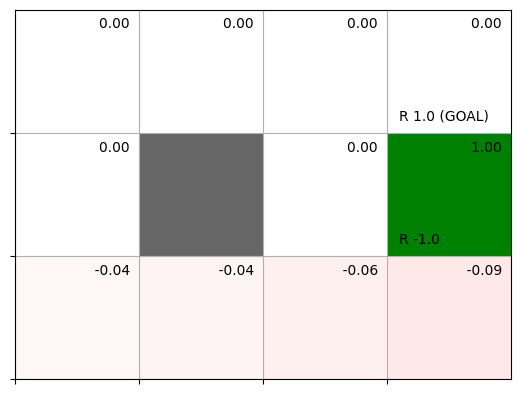

Ep[100]/St[43] state: (1, 3), action: 0:↓, reward: 1.0


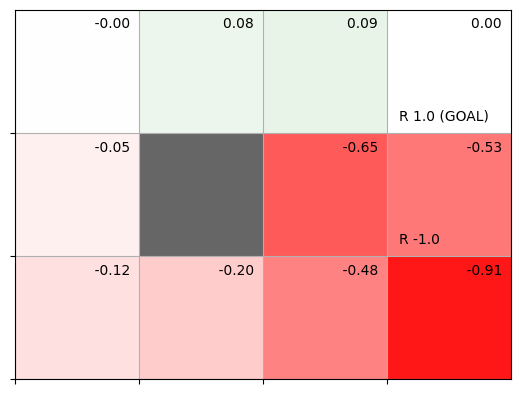

Ep[200]/St[96] state: (1, 3), action: 0:↓, reward: 1.0


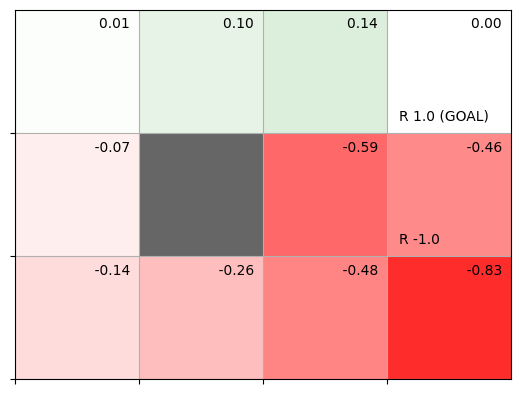

Ep[300]/St[56] state: (0, 2), action: 3:→, reward: 1.0


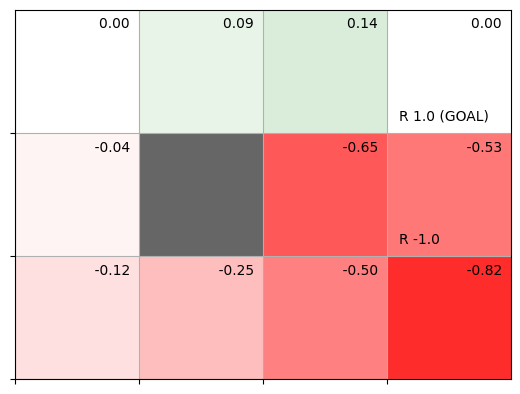

Ep[400]/St[6] state: (1, 3), action: 0:↓, reward: 1.0


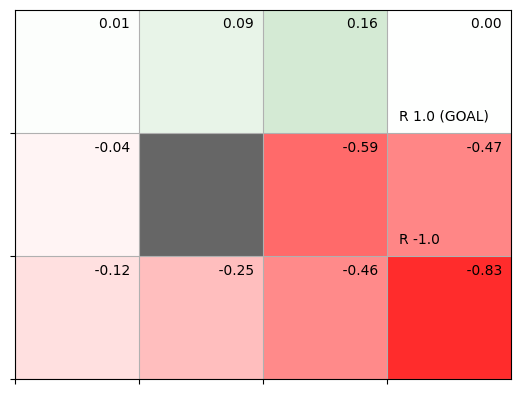

Ep[500]/St[86] state: (1, 3), action: 0:↓, reward: 1.0


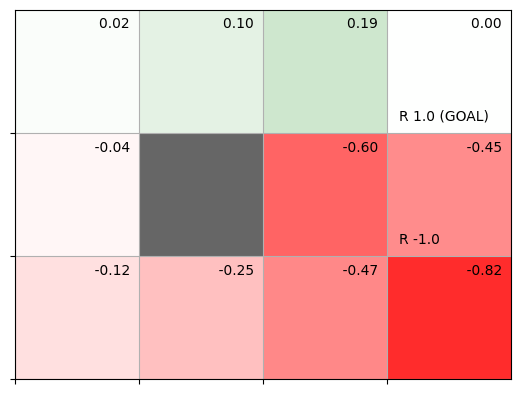

Ep[600]/St[24] state: (1, 3), action: 0:↓, reward: 1.0


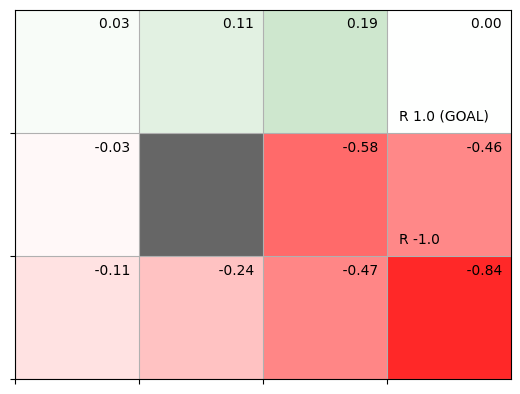

Ep[700]/St[65] state: (1, 3), action: 0:↓, reward: 1.0


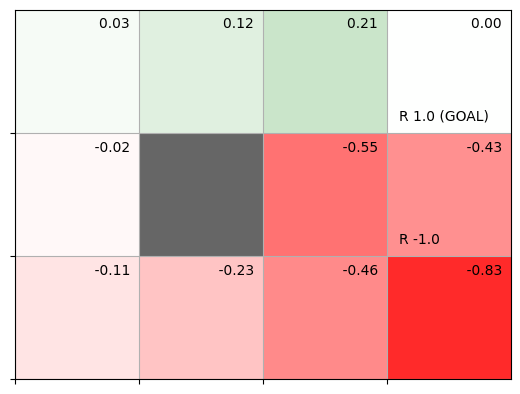

Ep[800]/St[36] state: (0, 2), action: 3:→, reward: 1.0


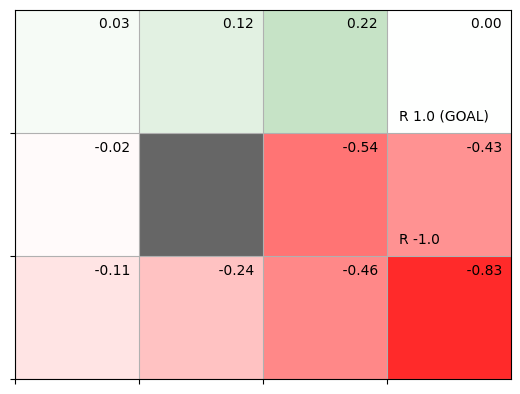

Ep[900]/St[8] state: (1, 3), action: 0:↓, reward: 1.0


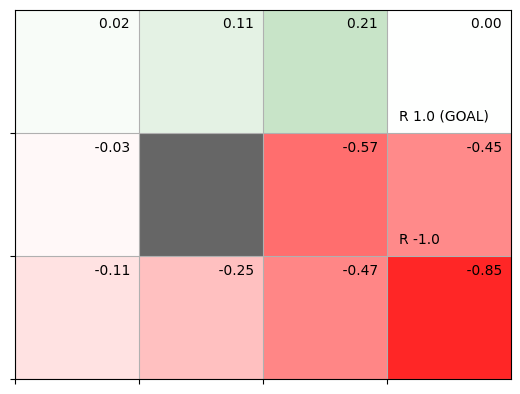

Result of eval V-map


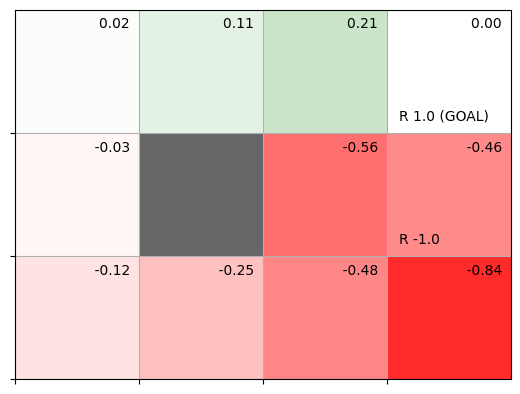

In [20]:
env = GridWorld()
agent = RandomAgent()

episodes = 1000
for episode in range(episodes):
    state = env.reset()
    agent.reset()
    step = 0

    # エピソード
    while True:
        # 状態sにおけるエージェントの方策πによる行動a
        action = agent.get_action(state)

        # 環境モデルを更新
        next_state, reward, done = env.step(action)

        # データ収集(サンプリング)
        agent.add(state, action, reward)

        if done: # エピソード終了
            # 学習
            agent.eval()
            break

        # 状態遷移(ここでは決定論的)
        state = next_state
        
        step += 1

    if episode % 100 == 0:
        print(f"Ep[{episode}]/St[{step}] state: {state}, action: {action}:{move(action)}, reward: {reward}")
        env.render_v(agent.V)

# モンテカルロ法による方策評価の結果
print('Result of eval V-map') 
env.render_v(agent.V)

#### モンテカルロ法による方策制御

+ 方策のgreedy化で方策を「改善」する
+ 各状態sでの方策の中で行動価値関数Qを最大にする行動aを選択する

$$\mu(s) = argmax_{a}Q(s,a)$$
$$\mu(s) = \sum_{s'} p(s'|s,a) {r(s,a,s') + \gamma V(s')}$$

1. 今回は、モンテカルロ法を用いて、方策評価でV(s)を計算した。
2. 一般的に環境モデル：　状態遷移モデルp(s'|s,a), 報酬r(s,a,s') はわからない
3. 行動価値関数Q(s,a)を直接最大かすればOK

##### モンテカルロ法の方策評価で、状態価値関数V(s)の更新を、行動価値関数Q(s)に変更して、方策評価を行う

状態価値関数Vに関しての評価と更新式
+ 一般的な式: $$V_{n}(s) = \frac{\sum^{n}_1 G^{(i)}}{n}$$
+ インクリメンタルな式: $$V_{n}(s) = V_{(n-1)}(s) + \frac{1}{n} \{{G^{(n)}-V_{n-1}(s)}\}$$

行動価値関数Qに関しての評価と更新式
+ 一般的な式: $$Q_{n}(s,a) = \frac{\sum^{n}_1 G^{(i)}}{n}$$
+ インクリメンタルな式: $$Q_{n}(s,a) = Q_{n-1}(s,a) + \frac{1}{n} \{{G^{(n)}-Q_{n-1}(s,a)}\}$$

In [22]:
# モンテカルロ法で行う計算自体は同じ

# モンテカルロ法を使った方策制御
class McAgent:
    def __init__(self):
        self.gamma = 0.9
        self.action_size=4

        random_actions = {
            0: .25, # 上
            1: .25, # 下
            2: .25, # 左
            3: .25, # 右
        }
        self.pi = defaultdict(lambda: random_actions) # 方策
        self.Q = defaultdict(lambda: 0) # 行動価値関数
        self.cnts = defaultdict(lambda: 0) # 状態sを経由した回数. インクリメンタル方式の価値関数Vを求める際に使う.
        self.memory = [] # (状態,行動,報酬)のデータ集

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    # 方策評価の更新式
    def update(self):
        G = 0
        for data in reversed(self.memory):
            state, action, reward = data
            G = reward + self.gamma * G
            key = (state, action) # 状態sのパターンから単に組み合わせとしてaが追加された. e.g.これまでの状態数をS8パターンとすると、各パターンでaが4パターンある場合, 8x4=32パターンの空間
            self.cnts[key] += 1 # 状態sで行動aを経由した回数
            self.Q[key] += (G - self.Q[key]) / self.cnts[key]

            self.pi[state] = greedy_probs(self.Q, state)



In [23]:
# greedyな行動をとる確率分布を返す関数.
# 状態stateにおいてQ関数の値が最大の行動だけをとる確率分布.
# ある状態においてQ関数の0番目の行動が最大だれば、{0: 1.0, 1: 0.0, 2: 0.0, 3: 0.0}を返す
def greedy_probs(Q, state, action_size=4):
    qs = [Q[(state, action)] for action in range(action_size)]
    max_action = np.argmax(qs)

    action_probs = {action: 0.0 for action in range(action_size)}
    action_probs[max_action] = 1.0 # Q関数が最大になる行動aのみ確率1にする
    return action_probs

##### 上記のQ関数に関するモンテカルロ法による方策評価と方策制御を適切に動作させるために、2つの改良を行う
1. greedyをε-greedyにする
2. インクリメンタルな方式の $\frac{1}{n}$ の部分を固定値α方式に変更
$$Q_{n}(s,a) = Q_{n-1}(s,a) + \alpha \{{G^{(n)}-Q_{n-1}(s,a)}\}$$

ε-greedyによる確率分布(方策)の取得

In [24]:
def greedy_probs(Q, state, epsilon=0, action_size=4):
    qs = [Q[(state,action)] for action in range(action_size)]
    max_action = np.argmax(qs)

    base_prob = epsilon / action_size
    action_probs = { action: base_prob for action in range(action_size) }
    # この時点でaction_probsは {0: ε/4, 1: ε/4, 2: ε/4, 3: ε/4}
    action_probs[max_action] += (1 - epsilon) # ε/4 + (1 - ε) = 1 - 3ε/4. sum = ε/4 + (1-3ε/4) + ε/4 + ε/4 = 1.0
    return action_probs

In [29]:
# 修正版モンテカルロ法を使った方策反復法の実装
class McAgent:
    def __init__(self):
        self.gamma = 0.9
        self.epsilon = 0.1 # ε-greedy法のε
        self.alpha = 0.1 # Q値を更新する際の固定値alpha
        self.action_size = 4

        random_actions = {
            0: .25, # ↑
            1: .25, # ↓
            2: .25, # ←
            3: .25, # →
        }

        self.pi = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = []

    # a ~ π(a|s)
    def get_action(self, action):
        action_probs = self.pi[state] # π(a|s)
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)
    
    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    # 方策の「評価」と「改善」
    def update(self): # エピソード終了時に1回実行される
        G = 0
        for data in reversed(self.memory):
            state, action, reward = data
            G = reward + self.gamma * G
            key = (state, action)
            self.Q[key] += (G - self.Q[key]) * self.alpha
            self.pi[state] = greedy_probs(self.Q, state, self.epsilon) # ε-greedy法


エピソード反復

Ep[0]/St[9] state: (0, 2), action: 3:→, reward: 1.0


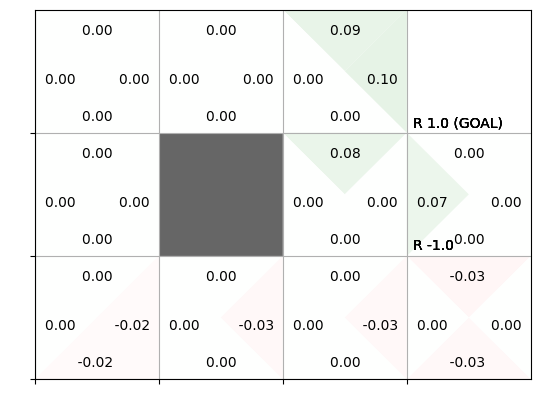

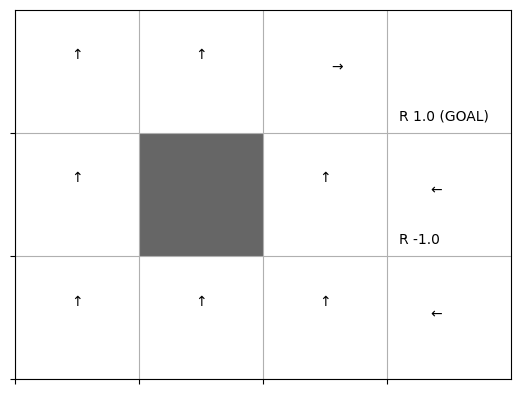

Ep[1000]/St[8] state: (0, 2), action: 3:→, reward: 1.0


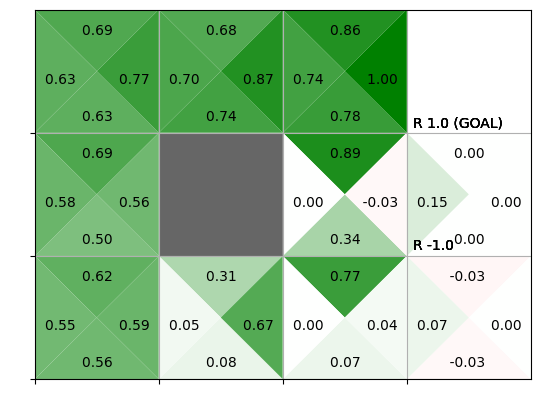

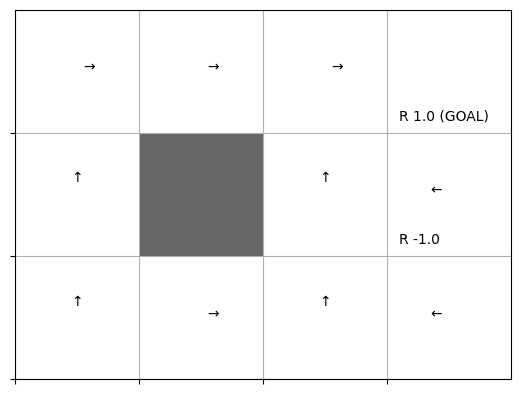

Ep[2000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


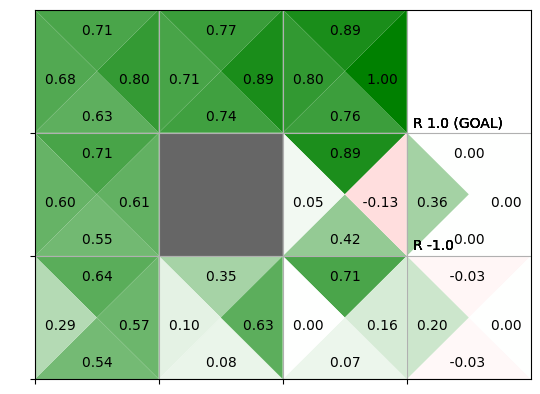

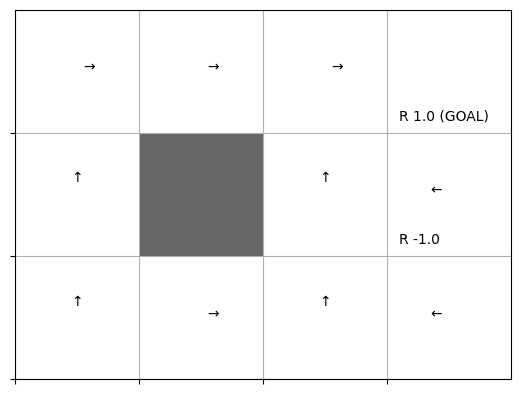

Ep[3000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


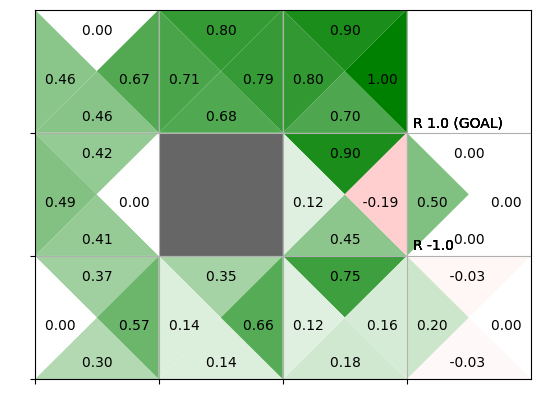

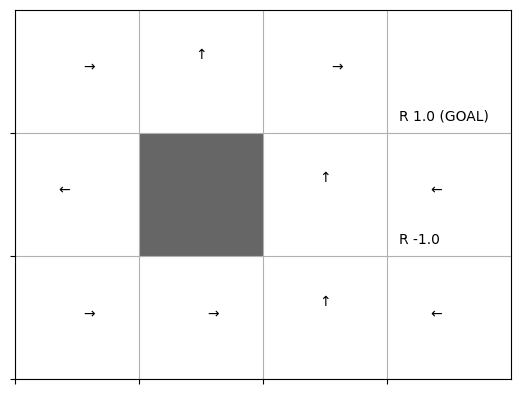

Ep[4000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


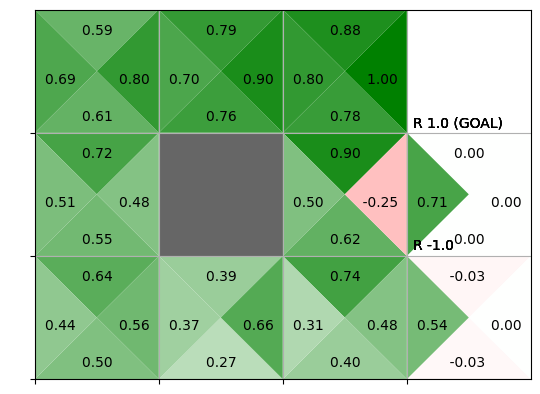

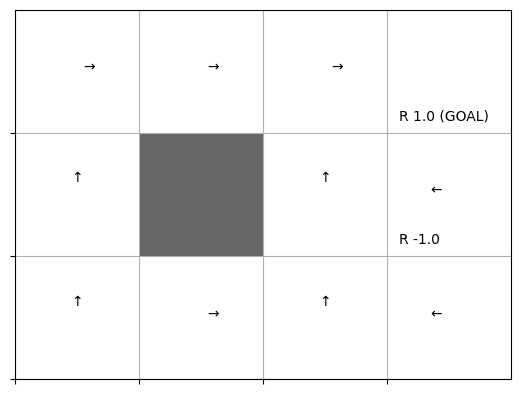

Ep[5000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


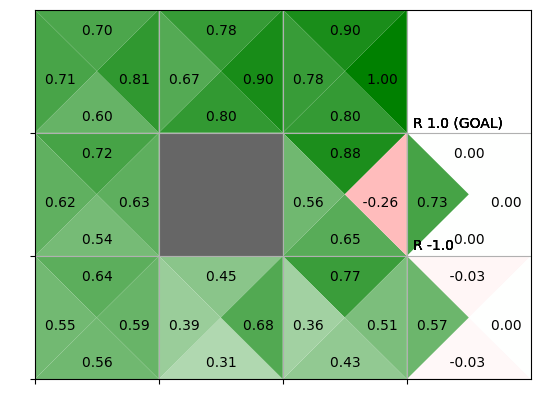

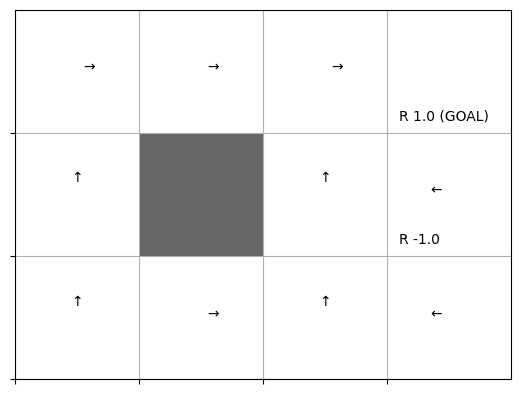

Ep[6000]/St[5] state: (0, 2), action: 3:→, reward: 1.0


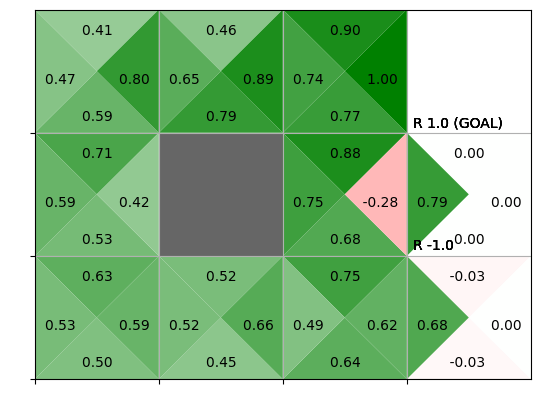

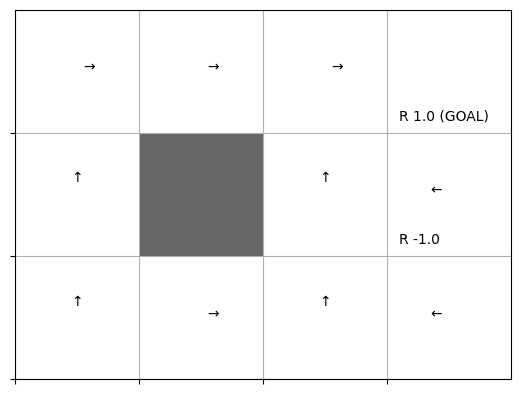

Ep[7000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


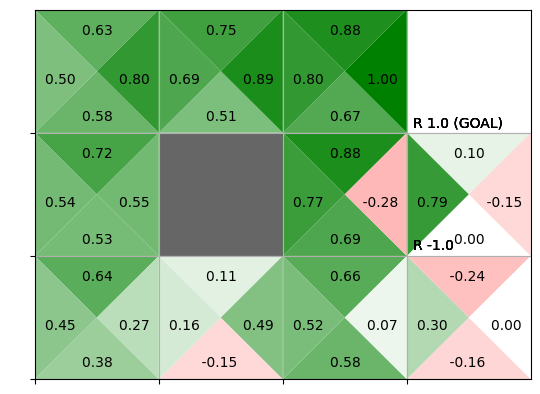

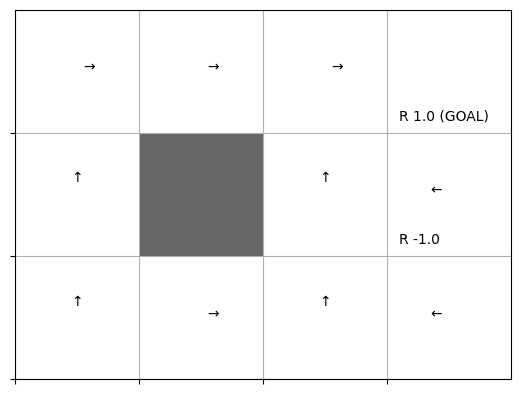

Ep[8000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


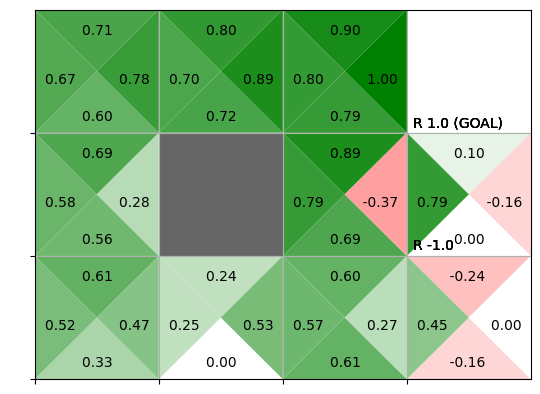

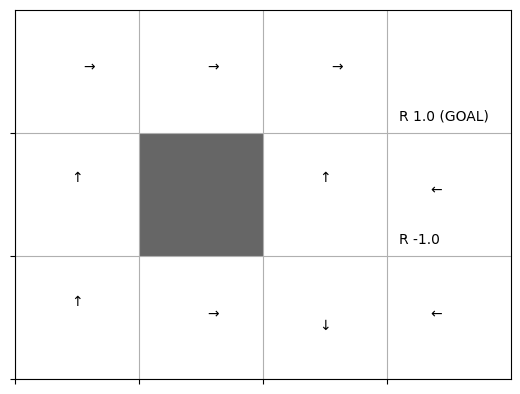

Ep[9000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


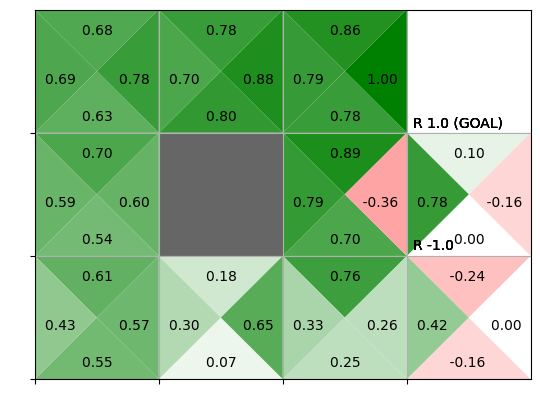

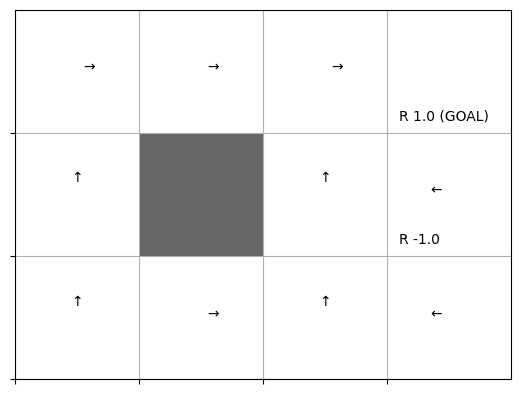

Result of eval Q-map


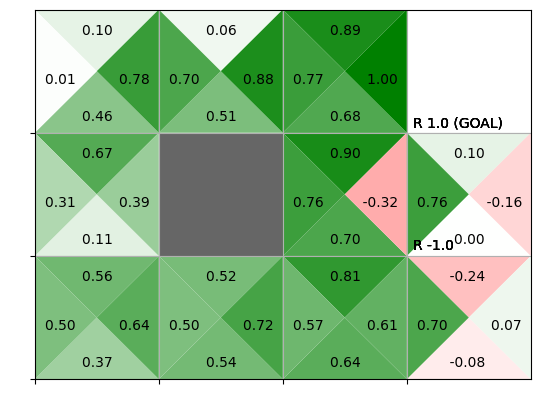

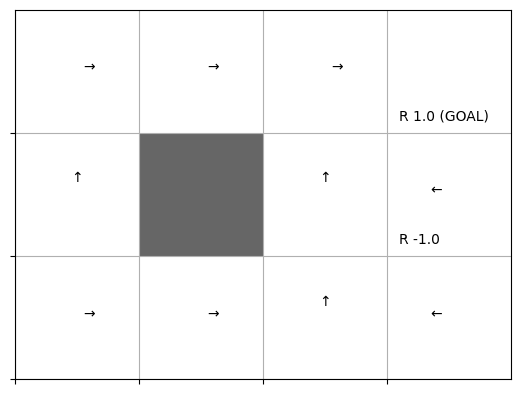

In [31]:
env = GridWorld()
agent = McAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()
    step = 0

    while True:
        # a ~ π(a|s)
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)
        agent.add(state, action, reward)

        if done:
            agent.update()
            break

        # 状態遷移は決定論 s' = f(s,a)
        state = next_state

        step += 1

    if episode % 1000 == 0:
        print(f"Ep[{episode}]/St[{step}] state: {state}, action: {action}:{move(action)}, reward: {reward}")
        env.render_q(agent.Q)

# モンテカルロ法による方策評価の結果
print('Result of eval Q-map') 
env.render_q(agent.Q)
